In [2]:
# Make src/ importable from the notebook
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader import generate_mock_dam_prices, save_prices

%matplotlib inline

In [3]:
from src.data_loader import generate_mock_dam_prices

# We need enough history for the model to have:
#   - lag features going back 1 week
#   - 14-day test window
#   - meaningful train data
# 6 months is comfortable.
start = pd.Timestamp("2024-01-01", tz="Europe/Athens")
end = pd.Timestamp("2024-07-01", tz="Europe/Athens")

prices = generate_mock_dam_prices(start, end)
print(f"Hourly prices: {len(prices)} rows")
print(f"Range: {prices.index.min()} → {prices.index.max()}")
print(f"Mean: {prices.mean():.2f}, std: {prices.std():.2f}")

Hourly prices: 4367 rows
Range: 2024-01-01 00:00:00+02:00 → 2024-06-30 23:00:00+03:00
Mean: 95.61, std: 27.52


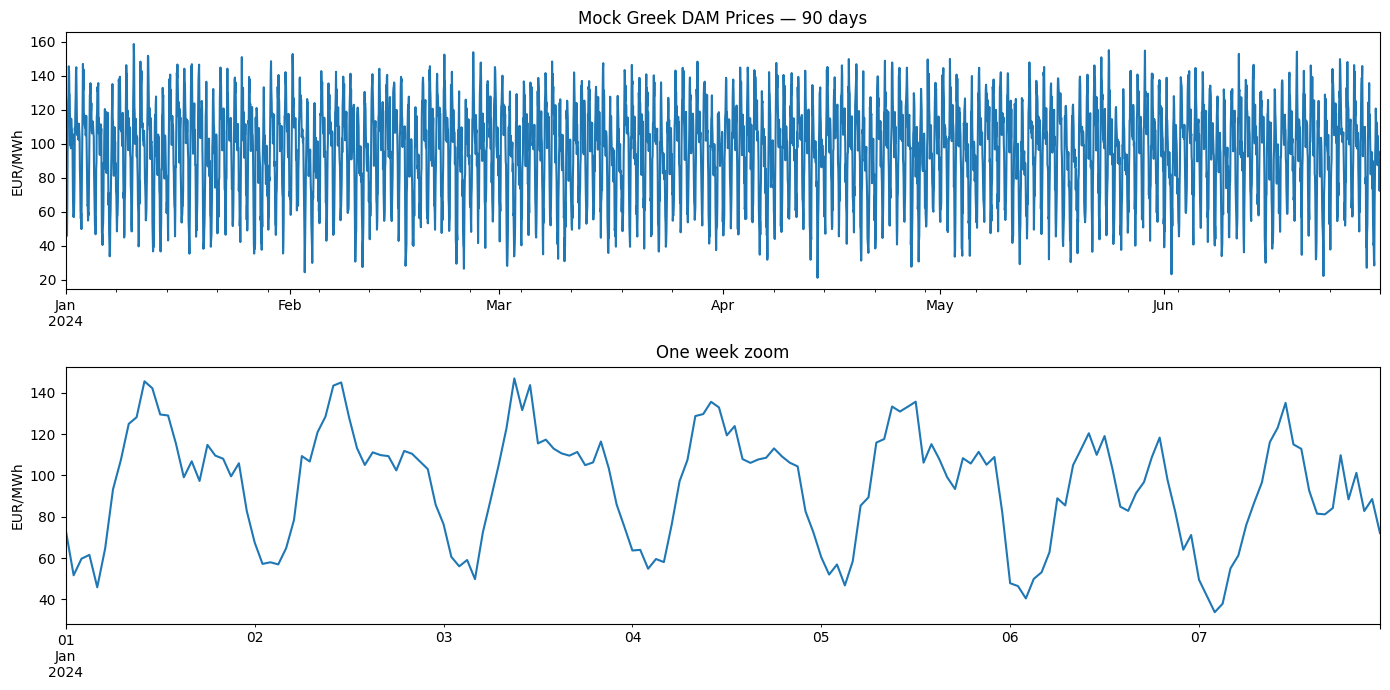

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Full series
prices.plot(ax=axes[0], title="Mock Greek DAM Prices — 90 days")
axes[0].set_ylabel("EUR/MWh")

# Zoom: one week, see daily/weekly patterns
prices.loc["2024-01-01":"2024-01-07"].plot(ax=axes[1], title="One week zoom")
axes[1].set_ylabel("EUR/MWh")

plt.tight_layout()
plt.show()

In [5]:
prices

2024-01-01 00:00:00+02:00    73.459962
2024-01-01 01:00:00+02:00    51.680127
2024-01-01 02:00:00+02:00    59.705327
2024-01-01 03:00:00+02:00    61.543756
2024-01-01 04:00:00+02:00    45.858007
                               ...    
2024-06-30 19:00:00+03:00    92.042394
2024-06-30 20:00:00+03:00    89.784963
2024-06-30 21:00:00+03:00    72.508748
2024-06-30 22:00:00+03:00    88.857229
2024-06-30 23:00:00+03:00    72.605716
Freq: h, Name: price_eur_mwh, Length: 4367, dtype: float64

In [6]:
prices.index.freq

<Hour>

In [8]:
gate_closure_hour = 12
horizon = tuple(range(12,36))
same_hour_lag_days = (1,2,7)
context_window = 1


In [9]:
forecast_times = prices.index[prices.index.hour == gate_closure_hour]
forecast_times

DatetimeIndex(['2024-01-01 12:00:00+02:00', '2024-01-02 12:00:00+02:00',
               '2024-01-03 12:00:00+02:00', '2024-01-04 12:00:00+02:00',
               '2024-01-05 12:00:00+02:00', '2024-01-06 12:00:00+02:00',
               '2024-01-07 12:00:00+02:00', '2024-01-08 12:00:00+02:00',
               '2024-01-09 12:00:00+02:00', '2024-01-10 12:00:00+02:00',
               ...
               '2024-06-21 12:00:00+03:00', '2024-06-22 12:00:00+03:00',
               '2024-06-23 12:00:00+03:00', '2024-06-24 12:00:00+03:00',
               '2024-06-25 12:00:00+03:00', '2024-06-26 12:00:00+03:00',
               '2024-06-27 12:00:00+03:00', '2024-06-28 12:00:00+03:00',
               '2024-06-29 12:00:00+03:00', '2024-06-30 12:00:00+03:00'],
              dtype='datetime64[us, Europe/Athens]', length=182, freq=None)

In [10]:
df = pd.DataFrame(index=forecast_times)
df

""
2024-01-01 12:00:00+02:00
2024-01-02 12:00:00+02:00
2024-01-03 12:00:00+02:00
2024-01-04 12:00:00+02:00
2024-01-05 12:00:00+02:00
...
2024-06-26 12:00:00+03:00
2024-06-27 12:00:00+03:00
2024-06-28 12:00:00+03:00
2024-06-29 12:00:00+03:00


In [11]:
prices_utc = prices.copy()
prices_utc.index = prices.index.tz_convert("UTC")

In [12]:
forecast_times_utc = forecast_times.tz_convert("UTC")
forecast_times_utc

DatetimeIndex(['2024-01-01 10:00:00+00:00', '2024-01-02 10:00:00+00:00',
               '2024-01-03 10:00:00+00:00', '2024-01-04 10:00:00+00:00',
               '2024-01-05 10:00:00+00:00', '2024-01-06 10:00:00+00:00',
               '2024-01-07 10:00:00+00:00', '2024-01-08 10:00:00+00:00',
               '2024-01-09 10:00:00+00:00', '2024-01-10 10:00:00+00:00',
               ...
               '2024-06-21 09:00:00+00:00', '2024-06-22 09:00:00+00:00',
               '2024-06-23 09:00:00+00:00', '2024-06-24 09:00:00+00:00',
               '2024-06-25 09:00:00+00:00', '2024-06-26 09:00:00+00:00',
               '2024-06-27 09:00:00+00:00', '2024-06-28 09:00:00+00:00',
               '2024-06-29 09:00:00+00:00', '2024-06-30 09:00:00+00:00'],
              dtype='datetime64[us, UTC]', length=182, freq=None)

In [13]:
prices_utc

2023-12-31 22:00:00+00:00    73.459962
2023-12-31 23:00:00+00:00    51.680127
2024-01-01 00:00:00+00:00    59.705327
2024-01-01 01:00:00+00:00    61.543756
2024-01-01 02:00:00+00:00    45.858007
                               ...    
2024-06-30 16:00:00+00:00    92.042394
2024-06-30 17:00:00+00:00    89.784963
2024-06-30 18:00:00+00:00    72.508748
2024-06-30 19:00:00+00:00    88.857229
2024-06-30 20:00:00+00:00    72.605716
Freq: h, Name: price_eur_mwh, Length: 4367, dtype: float64

In [15]:
df

""
2024-01-01 12:00:00+02:00
2024-01-02 12:00:00+02:00
2024-01-03 12:00:00+02:00
2024-01-04 12:00:00+02:00
2024-01-05 12:00:00+02:00
...
2024-06-26 12:00:00+03:00
2024-06-27 12:00:00+03:00
2024-06-28 12:00:00+03:00
2024-06-29 12:00:00+03:00


In [23]:
ts_utc = forecast_times_utc - pd.Timedelta(hours=1)
ts_utc

DatetimeIndex(['2024-01-01 09:00:00+00:00', '2024-01-02 09:00:00+00:00',
               '2024-01-03 09:00:00+00:00', '2024-01-04 09:00:00+00:00',
               '2024-01-05 09:00:00+00:00', '2024-01-06 09:00:00+00:00',
               '2024-01-07 09:00:00+00:00', '2024-01-08 09:00:00+00:00',
               '2024-01-09 09:00:00+00:00', '2024-01-10 09:00:00+00:00',
               ...
               '2024-06-21 08:00:00+00:00', '2024-06-22 08:00:00+00:00',
               '2024-06-23 08:00:00+00:00', '2024-06-24 08:00:00+00:00',
               '2024-06-25 08:00:00+00:00', '2024-06-26 08:00:00+00:00',
               '2024-06-27 08:00:00+00:00', '2024-06-28 08:00:00+00:00',
               '2024-06-29 08:00:00+00:00', '2024-06-30 08:00:00+00:00'],
              dtype='datetime64[us, UTC]', length=182, freq=None)

In [24]:
prices_utc.reindex(ts_utc)

2024-01-01 09:00:00+00:00    142.203098
2024-01-02 09:00:00+00:00    145.012540
2024-01-03 09:00:00+00:00    143.726989
2024-01-04 09:00:00+00:00    132.926859
2024-01-05 09:00:00+00:00    133.268498
                                ...    
2024-06-26 08:00:00+00:00    148.069855
2024-06-27 08:00:00+00:00    142.363636
2024-06-28 08:00:00+00:00    138.057653
2024-06-29 08:00:00+00:00    135.675923
2024-06-30 08:00:00+00:00    112.762917
Name: price_eur_mwh, Length: 182, dtype: float64

In [25]:
prices_utc.head(50)

2023-12-31 22:00:00+00:00     73.459962
2023-12-31 23:00:00+00:00     51.680127
2024-01-01 00:00:00+00:00     59.705327
2024-01-01 01:00:00+00:00     61.543756
2024-01-01 02:00:00+00:00     45.858007
2024-01-01 03:00:00+00:00     64.582564
2024-01-01 04:00:00+00:00     93.258152
2024-01-01 05:00:00+00:00    107.470059
2024-01-01 06:00:00+00:00    124.950670
2024-01-01 07:00:00+00:00    128.175649
2024-01-01 08:00:00+00:00    145.568895
2024-01-01 09:00:00+00:00    142.203098
2024-01-01 10:00:00+00:00    129.506020
2024-01-01 11:00:00+00:00    129.017930
2024-01-01 12:00:00+00:00    115.397341
2024-01-01 13:00:00+00:00     99.106422
2024-01-01 14:00:00+00:00    106.842702
2024-01-01 15:00:00+00:00     97.328939
2024-01-01 16:00:00+00:00    114.792174
2024-01-01 17:00:00+00:00    109.600593
2024-01-01 18:00:00+00:00    108.077038
2024-01-01 19:00:00+00:00     99.552564
2024-01-01 20:00:00+00:00    105.887635
2024-01-01 21:00:00+00:00     82.783002
2024-01-01 22:00:00+00:00     67.595603


In [26]:
for lag in (0, 1, 2, 3):
        ts_utc = forecast_times_utc - pd.Timedelta(hours=lag)
        df[f"ft_price_minus_{lag}h"] = prices_utc.reindex(ts_utc).values

In [27]:
df

,ft_price_minus_0h,ft_price_minus_1h,ft_price_minus_2h,ft_price_minus_3h
2024-01-01 12:00:00+02:00,129.506020,142.203098,145.568895,128.175649
2024-01-02 12:00:00+02:00,128.066195,145.012540,143.461547,128.489818
2024-01-03 12:00:00+02:00,115.514817,143.726989,131.607063,146.959530
2024-01-04 12:00:00+02:00,119.411058,132.926859,135.629281,129.704592
2024-01-05 12:00:00+02:00,135.700240,133.268498,130.933535,133.356500
...,...,...,...,...
2024-06-26 12:00:00+03:00,126.022132,148.069855,147.474305,121.100625
2024-06-27 12:00:00+03:00,125.267815,142.363636,118.220048,146.267591
2024-06-28 12:00:00+03:00,145.711128,138.057653,138.535872,135.081973
2024-06-29 12:00:00+03:00,104.442724,135.675923,109.364073,124.547276


In [30]:
for w in (24, 168):
        rolled = prices.rolling(window=w, min_periods=1)
        df[f"ft_mean_{w}h"] = rolled.mean().reindex(forecast_times).values
        df[f"ft_std_{w}h"] = rolled.std().reindex(forecast_times).values
        df[f"ft_max_{w}h"] = rolled.max().reindex(forecast_times).values
        df[f"ft_min_{w}h"] = rolled.min().reindex(forecast_times).values
        

In [32]:
df

,ft_price_minus_0h,ft_price_minus_1h,ft_price_minus_2h,ft_price_minus_3h,ft_mean_24h,ft_std_24h,ft_max_24h,ft_min_24h,ft_mean_168h,ft_std_168h,ft_max_168h,ft_min_168h
2024-01-01 12:00:00+02:00,129.506020,142.203098,145.568895,128.175649,94.458637,36.713052,145.568895,45.858007,94.458637,36.713052,145.568895,45.858007
2024-01-02 12:00:00+02:00,128.066195,145.012540,143.461547,128.489818,101.392379,26.452166,145.012540,56.942790,98.956200,30.126159,145.568895,45.858007
2024-01-03 12:00:00+02:00,115.514817,143.726989,131.607063,146.959530,99.896538,26.425792,146.959530,49.809042,99.326169,28.503615,146.959530,45.858007
2024-01-04 12:00:00+02:00,119.411058,132.926859,135.629281,129.704592,99.225885,25.605847,135.629281,54.841123,99.297853,27.565442,146.959530,45.858007
2024-01-05 12:00:00+02:00,135.700240,133.268498,130.933535,133.356500,98.258547,27.765000,135.700240,46.775405,99.069015,27.483751,146.959530,45.858007
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-26 12:00:00+03:00,126.022132,148.069855,147.474305,121.100625,99.593757,26.967630,148.069855,51.877551,96.585919,28.379980,149.795782,22.220022
2024-06-27 12:00:00+03:00,125.267815,142.363636,118.220048,146.267591,99.821729,25.695216,146.267591,57.169038,96.531183,28.314059,149.795782,22.220022
2024-06-28 12:00:00+03:00,145.711128,138.057653,138.535872,135.081973,100.454318,26.882177,145.711128,48.425736,96.594819,28.247576,149.795782,22.220022
2024-06-29 12:00:00+03:00,104.442724,135.675923,109.364073,124.547276,91.297076,30.089987,135.675923,27.053956,96.411421,28.236610,149.795782,22.220022


In [33]:
df2 = pd.DataFrame(index=forecast_times)

In [35]:
for lag in (0, 1, 2, 3):
    ts = forecast_times - pd.Timedelta(hours=lag)
    df2[f"ft_price_minus_{lag}h"] = prices.reindex(ts).values

In [36]:
df2

,ft_price_minus_0h,ft_price_minus_1h,ft_price_minus_2h,ft_price_minus_3h
2024-01-01 12:00:00+02:00,129.506020,142.203098,145.568895,128.175649
2024-01-02 12:00:00+02:00,128.066195,145.012540,143.461547,128.489818
2024-01-03 12:00:00+02:00,115.514817,143.726989,131.607063,146.959530
2024-01-04 12:00:00+02:00,119.411058,132.926859,135.629281,129.704592
2024-01-05 12:00:00+02:00,135.700240,133.268498,130.933535,133.356500
...,...,...,...,...
2024-06-26 12:00:00+03:00,126.022132,148.069855,147.474305,121.100625
2024-06-27 12:00:00+03:00,125.267815,142.363636,118.220048,146.267591
2024-06-28 12:00:00+03:00,145.711128,138.057653,138.535872,135.081973
2024-06-29 12:00:00+03:00,104.442724,135.675923,109.364073,124.547276


In [37]:
for w in (24, 168):
        rolled = prices.rolling(window=w, min_periods=1)
        df2[f"ft_mean_{w}h"] = rolled.mean().reindex(forecast_times).values
        df2[f"ft_std_{w}h"] = rolled.std().reindex(forecast_times).values
        df2[f"ft_max_{w}h"] = rolled.max().reindex(forecast_times).values
        df2[f"ft_min_{w}h"] = rolled.min().reindex(forecast_times).values

In [39]:
df.equals(df2)

True